# 📘 1. Introduction

## Simulating Agricultural Planting Data: Analysis & Visual Insights

This notebook simulates agricultural planting data across U.S. states from 1900–2023 for various plant types. We’ll perform:
- Data generation
- Descriptive statistics
- Trend analysis
- Heatmap visualization
- Distribution inspection


# 🧪 2. Data Generation

This step generates a random crop dataset for all 50 states, spanning from 1900 to 2025. Keep in mind that since the dataset is randomly generated, the output will vary each time the script is executed.

In [63]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Generate data
years = list(range(1900, 2025))
state_names = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut',
    'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
    'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan',
    'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
    'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia',
    'Wisconsin', 'Wyoming'
]

# state_names = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'Ohio', 'South Dakota', 'Wisconsin']
plants = ["Corn", "Wheat", "Soybean", "Sugarcane", "Rice"]

year_list, states_list, plants_list, values_list = [], [], [], []

for year in years:
    for plant in plants:
        for _ in range(20):
            year_list.append(year)
            states_list.append(random.choice(state_names))
            plants_list.append(plant)
            values_list.append(random.randint(100, 1000))

planting_acres_df = pd.DataFrame({
    'Year': year_list,
    'States': states_list,
    'Plant_Planted': plants_list,
    'Values': values_list
})

# Display DataFrame summary
print("Head of DataFrame:")
print(planting_acres_df.head())

Head of DataFrame:
   Year         States Plant_Planted  Values
0  1900         Oregon          Corn     400
1  1900  West Virginia          Corn     331
2  1900           Iowa          Corn     701
3  1900        Florida          Corn     729
4  1900   North Dakota          Corn     533


# 📊 3. Exploratory Data Analysis

### Summary Statistics

We begin with a look at the dataset structure and key statistics to understand the range and central tendencies of the generated values.



In [64]:
print("\nSize of DataFrame:")
print("Number of rows:", planting_acres_df.shape[0])
print("Number of columns:", planting_acres_df.shape[1])

print("\nBasic Statistics:")
print("Mean values:")
print(planting_acres_df.mean(numeric_only=True))
print("\nMedian values:")
print(planting_acres_df.median(numeric_only=True))
print("\nStandard deviations:")
print(planting_acres_df.std(numeric_only=True))
print("\nSummary statistics:")
print(planting_acres_df.describe())


Size of DataFrame:
Number of rows: 12500
Number of columns: 4

Basic Statistics:
Mean values:
Year      1962.00000
Values     551.51288
dtype: float64

Median values:
Year      1962.0
Values     551.0
dtype: float64

Standard deviations:
Year       36.084681
Values    259.727387
dtype: float64

Summary statistics:
               Year        Values
count  12500.000000  12500.000000
mean    1962.000000    551.512880
std       36.084681    259.727387
min     1900.000000    100.000000
25%     1931.000000    326.000000
50%     1962.000000    551.000000
75%     1993.000000    777.000000
max     2024.000000   1000.000000


# 🗺️4 . Choropleth Map: Average Planting Value by State

### Mapping State-Level Planting Values

We’ll use `geopandas` and built-in U.S. state boundaries to visualize average planting values by state. This provides spatial context to the data distribution.


C:\Users\dshrestha\AppData\Local\Temp\ipykernel_30084\2261004606.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  usa = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


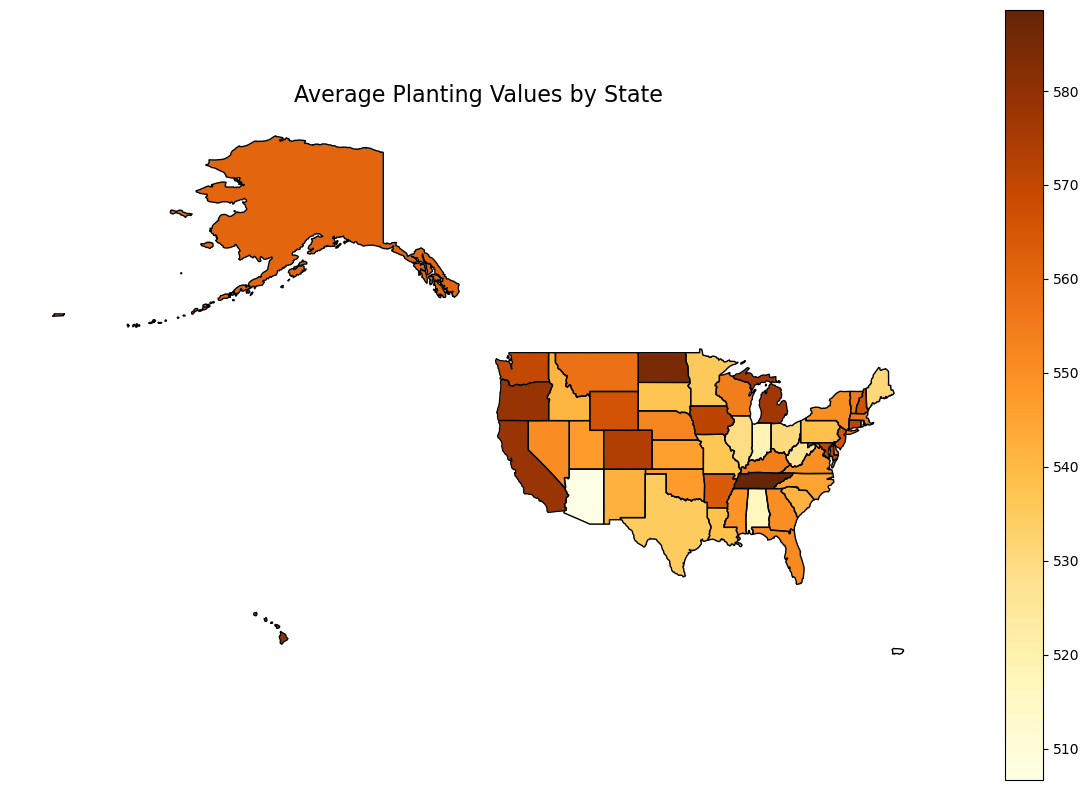

In [65]:
import geopandas as gpd

# Load US states shapefile from geopandas built-in datasets
usa = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
usa = usa[(usa['continent'] == 'North America') & (usa['name'] == 'United States of America')]

# Replace with US states shapefile
us_states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")

# Prepare state average values
state_avg = planting_acres_df.groupby("States")["Values"].mean().reset_index()
state_avg.columns = ["name", "avg_value"]

# Merge data with GeoDataFrame
us_states = us_states.merge(state_avg, left_on="name", right_on="name", how="left")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
us_states.boundary.plot(ax=ax, linewidth=1, color='black')
us_states.plot(column="avg_value", cmap="YlOrBr", linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

ax.set_title("Average Planting Values by State", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.savefig("choropleth_avg_values.png")
plt.show()


# 📈 5. Line Plot: Mean Value per Year

### Mean Value Trends Over the Years

This line plot helps track how the mean planting values have evolved from 1900 to 2023.


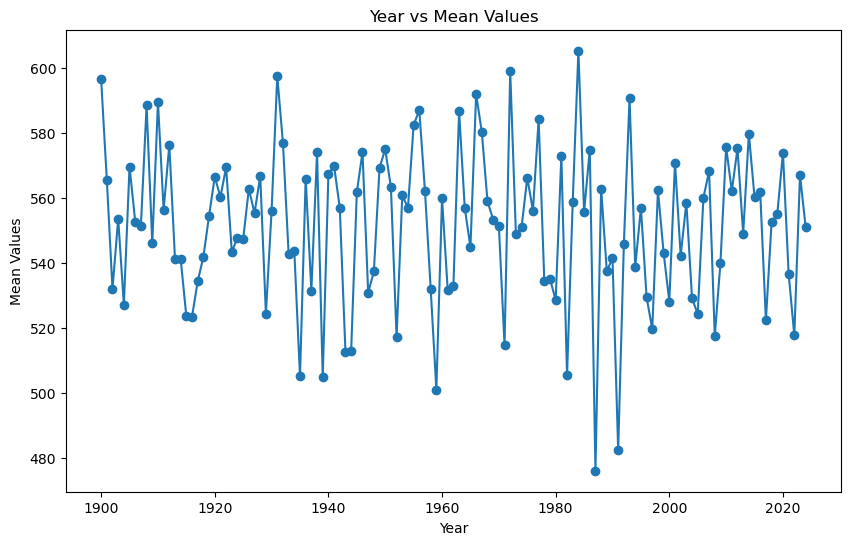

In [66]:
# Line Plot: Year vs Mean Values
plt.figure(figsize=(10, 6))
yearly_mean = planting_acres_df.groupby('Year')['Values'].mean()
yearly_mean.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Values')
plt.title('Year vs Mean Values')
plt.show()

# 🌡️ 6. Heatmap: States vs Year

### Heatmap of Average Values Across States by Year

This heatmap highlights geographical and temporal planting trends.

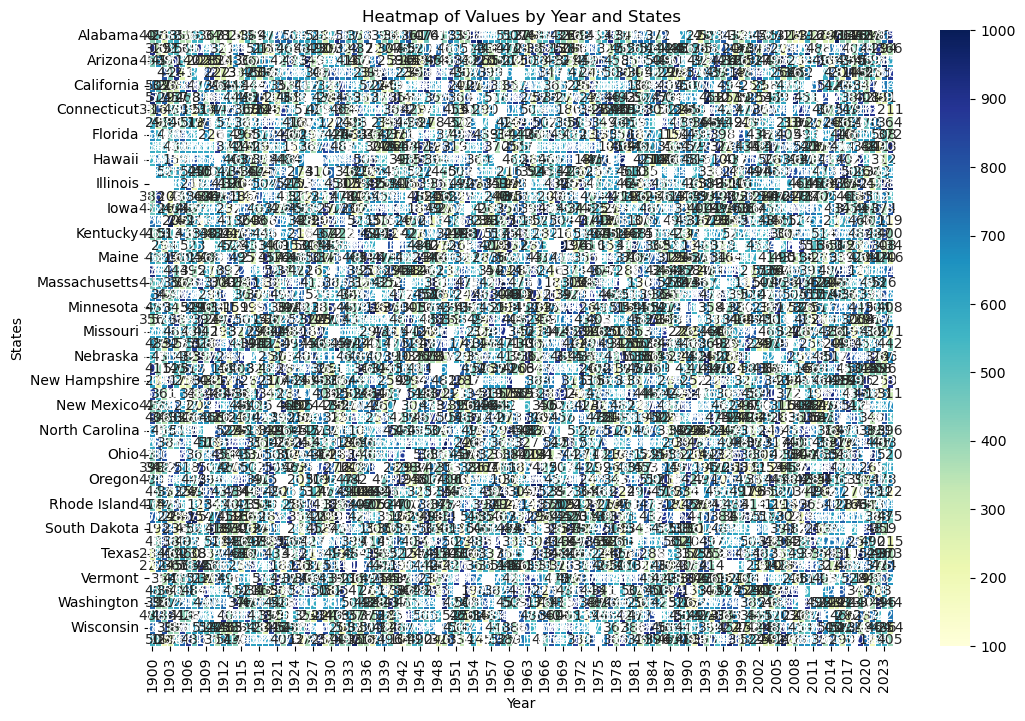

In [67]:
# Heatmap: States vs Year
pivot_df = planting_acres_df.pivot_table(index='States', columns='Year', values='Values', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5)
plt.title('Heatmap of Values by Year and States')
plt.show()

# 🧠 Oouch... Didn't like it? Let's use some filters.

### Why filter?

The dataset covers all 50 U.S. states over 120+ years, making full heatmaps dense and hard to interpret. By filtering to the top 10 states with the highest average values, we improve clarity and make high-value trends stand out visually.

In [68]:
# Get top 10 states by mean 'Values'
top_states = planting_acres_df.groupby('States')['Values'].mean().sort_values(ascending=False).head(10).index.tolist()

# Filter the main DataFrame
filtered_df = planting_acres_df[planting_acres_df['States'].isin(top_states)]


# 🔍 7. Focused Heatmap: Last 10 Years for Top 10 states.

### Zooming In: State-wise Planting Trends (Last 10 Years for Top 10 states)

We filter down to the most recent 10 years for readability and relevance.

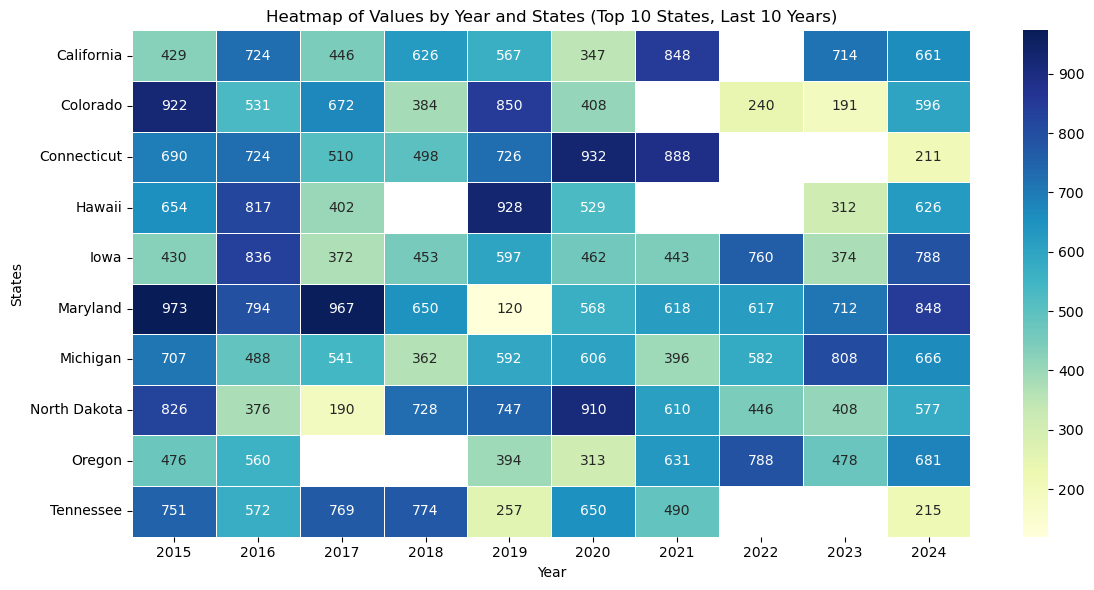

In [69]:
# Get the 10 most recent years
recent_years = sorted(planting_acres_df['Year'].unique())[-10:]

# Filter the original DataFrame to top states and recent years
filtered_recent_df = filtered_df[filtered_df['Year'].isin(recent_years)]

# Pivot table for heatmap
pivot_df = filtered_recent_df.pivot_table(index='States', columns='Year', values='Values', aggfunc='mean')

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5)
plt.title('Heatmap of Values by Year and States (Top 10 States, Last 10 Years)')
plt.tight_layout()
plt.savefig('heatmap_top10_last10years.png')  # Save as PNG
plt.show()


# 🧮 8. Normalized Z-Score Heatmap

### Normalized Heatmap: Detecting Outliers

This Z-score normalized heatmap shows deviations from each state’s average — helping identify unusually high or low years.

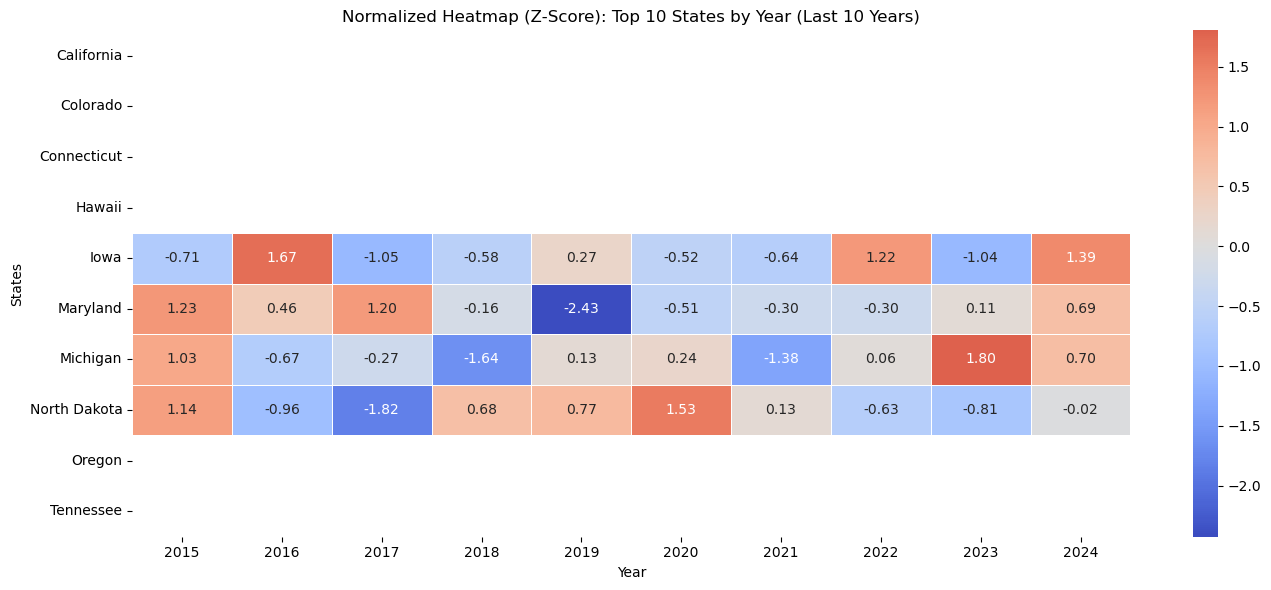

In [70]:
from scipy.stats import zscore

# Filter to last 10 years
recent_years = sorted(planting_acres_df['Year'].unique())[-10:]
filtered_recent_df = filtered_df[filtered_df['Year'].isin(recent_years)]

# Create pivot table for the filtered data
pivot_df = filtered_recent_df.pivot_table(index='States', columns='Year', values='Values', aggfunc='mean')

# Normalize using Z-score
normalized = pivot_df.apply(zscore, axis=1)

# Plot normalized heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(normalized, cmap='coolwarm', center=0, linewidths=.5, annot=True, fmt='.2f')
plt.title('Normalized Heatmap (Z-Score): Top 10 States by Year (Last 10 Years)')
plt.tight_layout()
plt.savefig('zscore_heatmap_top10_last10years.png')  # Save as PNG
plt.show()


# 🎨 9. Enhanced Heatmap Styling

### Enhanced Aesthetics

Rotated labels, colorbars, and improved layout make this visualization publication-ready.

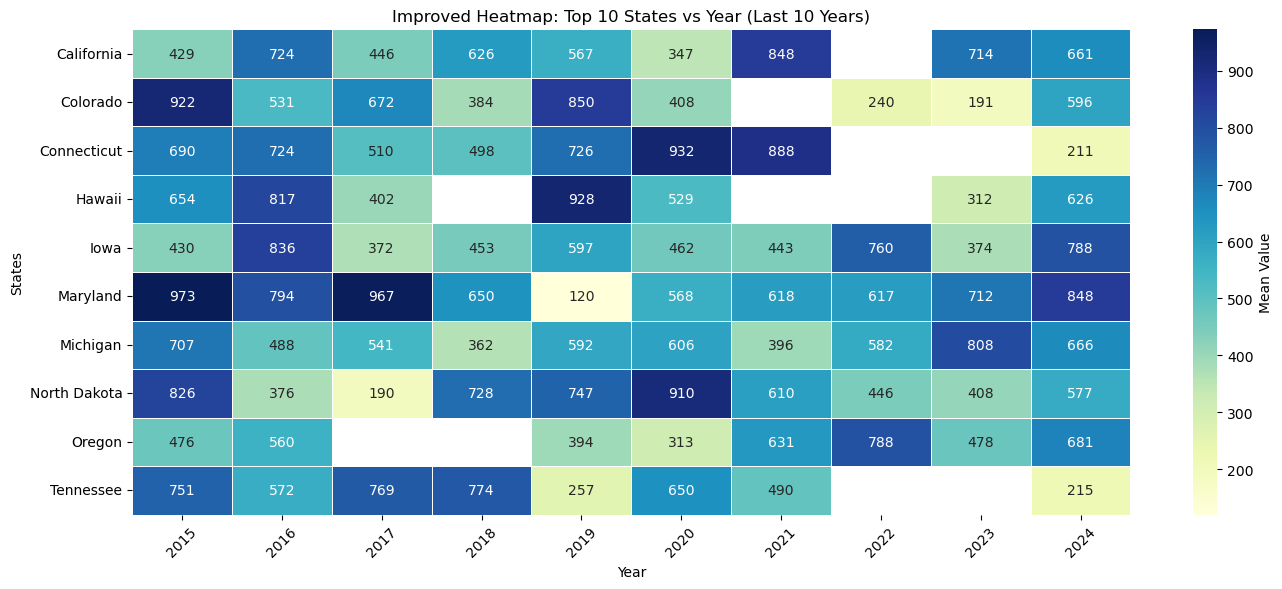

In [71]:
# Filter the data to the top 10 states and last 10 years
recent_years = sorted(planting_acres_df['Year'].unique())[-10:]
filtered_recent_df = filtered_df[filtered_df['Year'].isin(recent_years)]

# Create pivot table for the filtered data
pivot_df = filtered_recent_df.pivot_table(index='States', columns='Year', values='Values', aggfunc='mean')

# Improved heatmap with color bar and state names
plt.figure(figsize=(14, 6))
ax = sns.heatmap(pivot_df, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5, cbar_kws={'label': 'Mean Value'})
plt.xticks(rotation=45)
plt.title('Improved Heatmap: Top 10 States vs Year (Last 10 Years)')
plt.tight_layout()

# Save the plot as a PNG
plt.savefig('improved_heatmap_top10_last10years.png')

# Show the plot
plt.show()


# 📦 10. Boxplot: Distribution by Plant Type

### How Do Different Plants Compare?

Boxplots show the spread and central tendencies for each plant type's values.

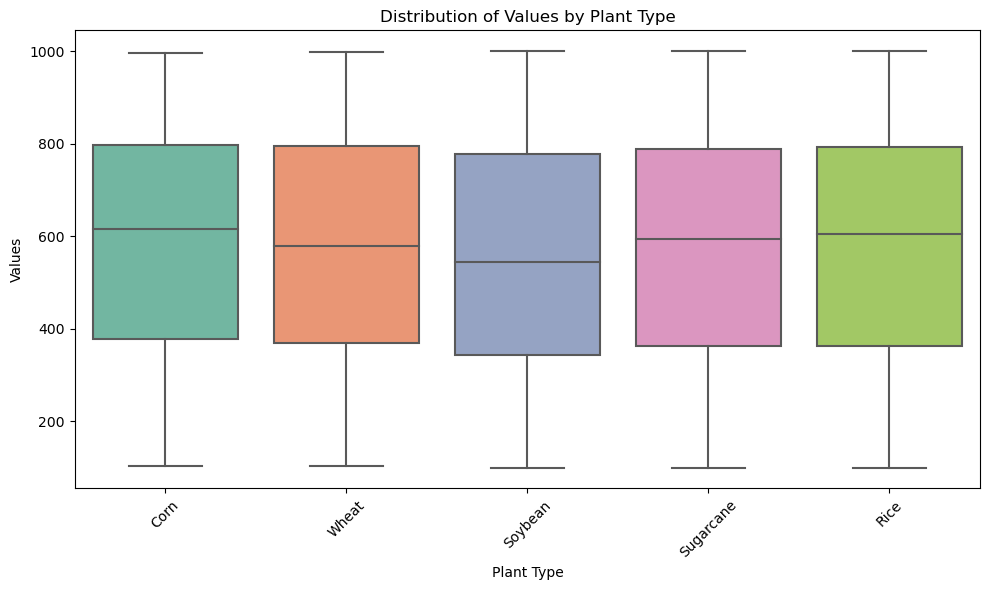

In [72]:
import seaborn as sns

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Plant_Planted', y='Values', data=filtered_df, palette='Set2')
plt.xlabel('Plant Type')
plt.ylabel('Values')
plt.title('Distribution of Values by Plant Type')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot as a PNG
plt.savefig('boxplot_distribution_by_plant_type.png')

# Show the plot
plt.show()


# 💾 11. Save the Dataset

### Export Final Dataset

For reproducibility and sharing, we export the simulated dataset as a CSV.

In [73]:
# Save to CSV
file_path = r'C:\Users\dshrestha\Downloads\planting_acres_data.csv'
planting_acres_df.to_csv(file_path, index=False)